# NYC Residential Housing Property Sales (2019-2024) End-to-End Data Pipeline Run Report (Part-2) Prediction Enhancement Plus AI Assitant Integration
By Yue Ru (Norton) Li, Chunhong Zhao, and Muling Wu
<br> Nortonlyr@gmail.com
<br> zhaoch@tcu.edu.cn
<br> Run the notebook in the Google Colab Environment
<br> Part-1 Notebook reference: https://github.com/nortonlyr/NYC_OPEN_DATA_2025/blob/main/NYC_Property_Sales_MLModel_End2End.ipynb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


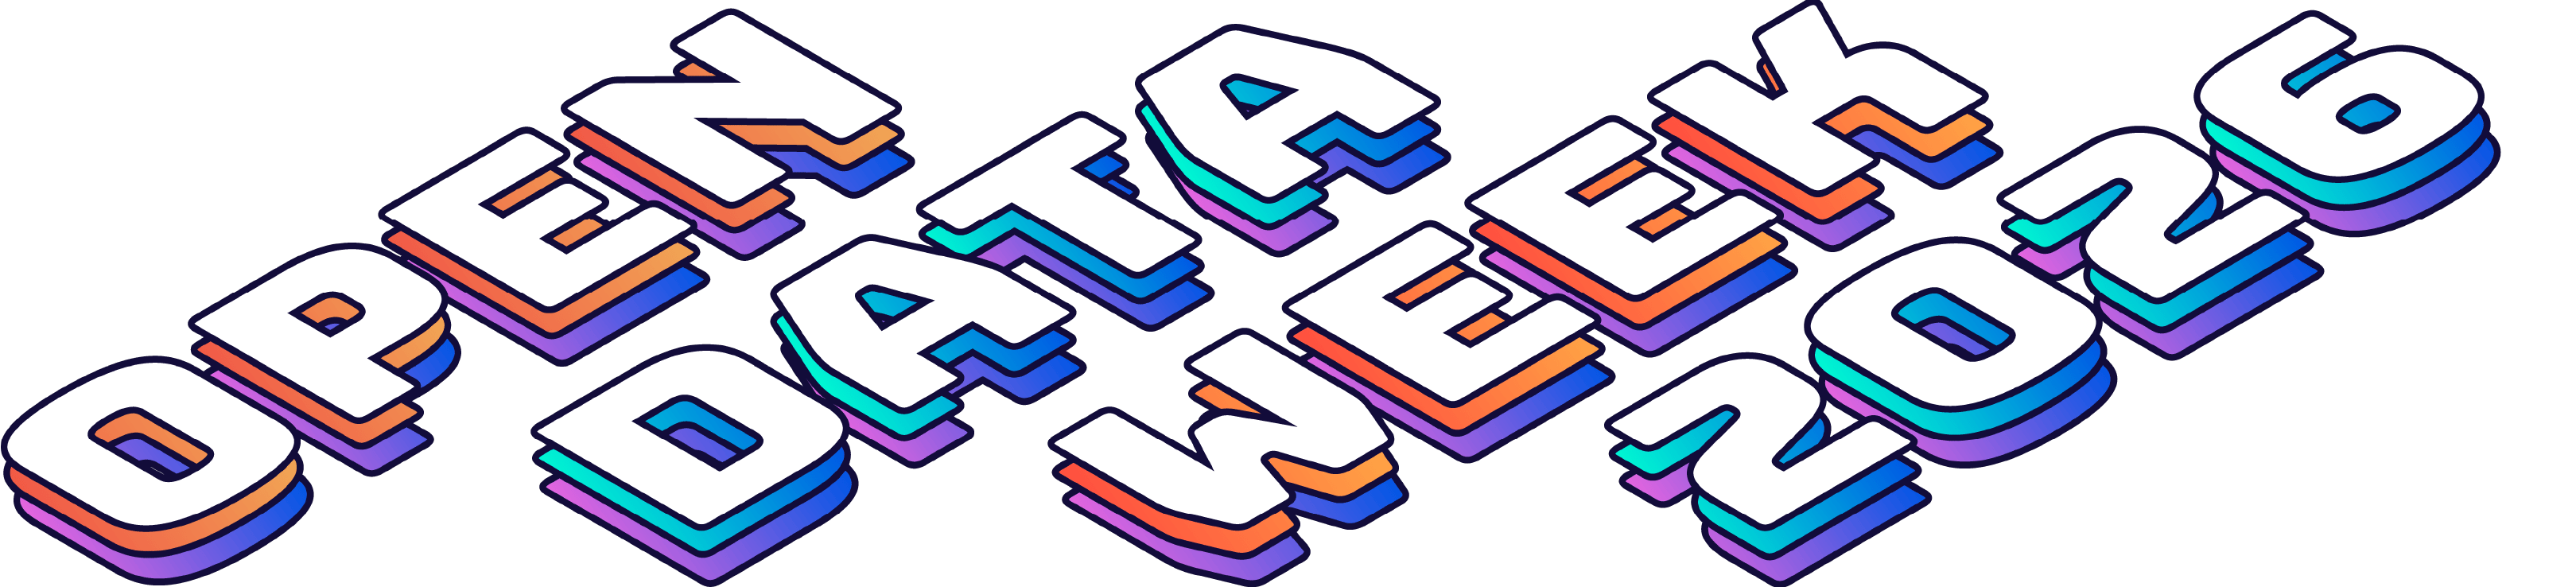

In [ ]:
# just for loading the event logo
from PIL import Image
import IPython.display as display
img = Image.open("/content/drive/My Drive/Colab Notebooks/Open_Data/NYC-Dept-Finance-Data/OPW_2026.jpg")  # Replace with your file name
display.display(img)

In [ ]:
import pandas as pd

# Set options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Now you can display your DataFrame
# For example:
# display(your_dataframe)

# Data Source Collection
#### Combine all the segment dataset from NYC Dept of Finance Website and DOB Permit Open DATA NYC Website
## The Dept of Finance obtain via Excel sheet download
#### reference: https://www.nyc.gov/site/finance/property/property-annualized-sales-update.page
#### https://www.nyc.gov/site/finance/property/definitions-of-property-assessment-terms.page#
## The DOB Permit data obtain via API queries
#### https://data.cityofnewyork.us/Housing-Development/DOB-Permit-Issuance/ipu4-2q9a/about_data


In [ ]:
# # Only need to combine once
# # google colab default storage location: /content/drive/My Drive/Colab Notebooks/

# import os
# # Change to the directory where the notebook is saved
# os.chdir('/content/drive/My Drive/Colab Notebooks/Open_Data/NYC-Dept-Finance-Data')

# import os
# import pandas as pd

# # Specify the folder path where your Excel files are located
# folder_path = '/content/drive/My Drive/Colab Notebooks/Open_Data/NYC-Dept-Finance-Data/dept_finance_source_data'

# # Get a list of all Excel files in the folder
# file_list = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

# # Initialize an empty list to hold DataFrames
# dfs = []

# # Loop through the file list and read each Excel file
# for file in file_list:
#     file_path = os.path.join(folder_path, file)  # Construct full file path
#     df = pd.read_excel(file_path,header=6)  # Read the Excel file into a DataFrame
#     df.columns = df.columns.str.replace('\n', ' ').str.strip().str.replace(' ', '_')

#     df = df.loc[:, ~df.columns.duplicated()]
#     dfs.append(df)  # Append the DataFrame to the list
# # print(dfs)
# # Combine all DataFrames in the list into one large DataFrame
# combined_df_2019_2024 = pd.concat(dfs, ignore_index=True)

# combined_df_2019_2024.head()

In [ ]:
# combined_df_2019_2024 = combined_df_2019_2024.drop(index=0).reset_index(drop=True)
# combined_df_2019_2024.head()

# combined_df_2019_2024.to_csv(f'{folder_path}/nyc_property_sale_2019-2024.csv', index=False)  # Save to CSV

# Exploratory Data Analysis (EDA) - Data Wrangling

In [ ]:
import pandas as pd

import os
# Change to the directory where the notebook is saved
folder_path = '/content/drive/My Drive/Colab Notebooks/Open_Data/NYC-Dept-Finance-Data/dept_finance_source_data'
os.chdir(folder_path)
pd.set_option('display.max_columns', None)

# Data source: https://www.nyc.gov/site/finance/property/property-annualized-sales-update.page
file = 'nyc_property_sale_2019-2024.csv'
nyc_sales_df = pd.read_csv(file)

In [ ]:
nyc_sales_df.head()

,BOROUGH,NEIGHBORHOOD,BUILDING_CLASS_CATEGORY,TAX_CLASS_AT_PRESENT,BLOCK,LOT,EASE-MENT,BUILDING_CLASS_AT_PRESENT,ADDRESS,APARTMENT_NUMBER,ZIP_CODE,RESIDENTIAL_UNITS,COMMERCIAL_UNITS,TOTAL__UNITS,LAND__SQUARE_FEET,GROSS__SQUARE_FEET,YEAR_BUILT,TAX_CLASS_AT_TIME_OF_SALE,BUILDING_CLASS_AT_TIME_OF_SALE,SALE_PRICE,SALE_DATE
0,1.0,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,372.0,36.0,NaN,S2,19 AVENUE D,NaN,10009.0,2.0,1.0,3.0,826.0,2481.0,1900.0,1.0,S2,1.0,2023-01-20
1,1.0,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,7.0,NaN,S2,49 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1725.0,2304.0,1880.0,1.0,S2,0.0,2023-11-02
2,1.0,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,8.0,NaN,S2,51 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1530.0,1920.0,1880.0,1.0,S2,0.0,2023-11-02
3,1.0,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,376.0,25.0,NaN,C3,266 EAST 7TH,NaN,10009.0,4.0,0.0,4.0,2059.0,3764.0,1900.0,2.0,C3,0.0,2023-11-09
4,1.0,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376.0,41.0,NaN,C4,"745 EAST 6TH STREET, 3D",NaN,10009.0,28.0,0.0,28.0,4542.0,18254.0,1900.0,2.0,C4,625000.0,2023-12-13


In [ ]:
nyc_sales_df.BOROUGH.value_counts()
# 1 -> Manhattan
# 2 -> Bronx
# 3 -> Brooklyn
# 4 -> Queens
# 5 -> Staten Island

,count
BOROUGH,
4.0,156033
3.0,142624
1.0,109394
5.0,49695
2.0,42029


In [ ]:
print(nyc_sales_df.shape)
# Check for missing values in 'BOROUGH' column
print(nyc_sales_df['BOROUGH'].isnull().sum())
# Fill NaN values with 0 and then convert 'BOROUGH' column to integer type
nyc_sales_df['BOROUGH'] = nyc_sales_df['BOROUGH'].fillna(0).astype(int)
print(nyc_sales_df.dtypes)
nyc_sales_df.head()

(499799, 21)
24
BOROUGH                             int64
NEIGHBORHOOD                       object
BUILDING_CLASS_CATEGORY            object
TAX_CLASS_AT_PRESENT               object
BLOCK                             float64
LOT                               float64
EASE-MENT                         float64
BUILDING_CLASS_AT_PRESENT          object
ADDRESS                            object
APARTMENT_NUMBER                   object
ZIP_CODE                          float64
RESIDENTIAL_UNITS                 float64
COMMERCIAL_UNITS                  float64
TOTAL__UNITS                      float64
LAND__SQUARE_FEET                 float64
GROSS__SQUARE_FEET                float64
YEAR_BUILT                        float64
TAX_CLASS_AT_TIME_OF_SALE         float64
BUILDING_CLASS_AT_TIME_OF_SALE     object
SALE_PRICE                        float64
SALE_DATE                          object
dtype: object


,BOROUGH,NEIGHBORHOOD,BUILDING_CLASS_CATEGORY,TAX_CLASS_AT_PRESENT,BLOCK,LOT,EASE-MENT,BUILDING_CLASS_AT_PRESENT,ADDRESS,APARTMENT_NUMBER,ZIP_CODE,RESIDENTIAL_UNITS,COMMERCIAL_UNITS,TOTAL__UNITS,LAND__SQUARE_FEET,GROSS__SQUARE_FEET,YEAR_BUILT,TAX_CLASS_AT_TIME_OF_SALE,BUILDING_CLASS_AT_TIME_OF_SALE,SALE_PRICE,SALE_DATE
0,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,372.0,36.0,NaN,S2,19 AVENUE D,NaN,10009.0,2.0,1.0,3.0,826.0,2481.0,1900.0,1.0,S2,1.0,2023-01-20
1,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,7.0,NaN,S2,49 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1725.0,2304.0,1880.0,1.0,S2,0.0,2023-11-02
2,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,8.0,NaN,S2,51 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1530.0,1920.0,1880.0,1.0,S2,0.0,2023-11-02
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,376.0,25.0,NaN,C3,266 EAST 7TH,NaN,10009.0,4.0,0.0,4.0,2059.0,3764.0,1900.0,2.0,C3,0.0,2023-11-09
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376.0,41.0,NaN,C4,"745 EAST 6TH STREET, 3D",NaN,10009.0,28.0,0.0,28.0,4542.0,18254.0,1900.0,2.0,C4,625000.0,2023-12-13


In [ ]:
nyc_sales_df['BOROUGH'].value_counts()

,count
BOROUGH,
4,156033
3,142624
1,109394
5,49695
2,42029
0,24


In [ ]:
nyc_sales_df.TAX_CLASS_AT_TIME_OF_SALE.value_counts()

,count
TAX_CLASS_AT_TIME_OF_SALE,
1.0,247353
2.0,219738
4.0,32684


### Check the data type for each column

In [ ]:
nyc_sales_df.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"})

,column_name,data_type
0,BOROUGH,int64
1,NEIGHBORHOOD,object
2,BUILDING_CLASS_CATEGORY,object
3,TAX_CLASS_AT_PRESENT,object
4,BLOCK,float64
5,LOT,float64
6,EASE-MENT,float64
7,BUILDING_CLASS_AT_PRESENT,object
8,ADDRESS,object
9,APARTMENT_NUMBER,object


### This Study only foucs on the Residential Tax class (Class 1: Most residential property of up to three units (including family homes and small stores or offices with one or two apartments attached), and most condominiums that are not more than three stories.)

In [ ]:
nyc_sales_df_2 = nyc_sales_df[nyc_sales_df['TAX_CLASS_AT_TIME_OF_SALE'] == 1.0]
nyc_sales_df_2.shape

(247353, 21)

### Add new create cloumn Borough-Block-Lot (BBL)

In [ ]:
# boro*1000000000+block*10000+lot

In [ ]:
# Create the 'bbl' column and convert to integer
nyc_sales_df_2.loc[:, 'bbl'] = (nyc_sales_df_2['BOROUGH'] * 1000000000 + nyc_sales_df_2['BLOCK'] * 10000 + nyc_sales_df_2['LOT']).astype(int)

# Convert 'bbl' column to string type
nyc_sales_df_2.loc[:, 'bbl'] = nyc_sales_df_2['bbl'].astype(str)

# Display the first few rows with the new 'bbl' column
nyc_sales_df_2.head()

/tmp/ipython-input-3872222041.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc_sales_df_2.loc[:, 'bbl'] = (nyc_sales_df_2['BOROUGH'] * 1000000000 + nyc_sales_df_2['BLOCK'] * 10000 + nyc_sales_df_2['LOT']).astype(int)
/tmp/ipython-input-3872222041.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1003720036' '1003860007' '1003860008' ... '1021570024' '1021790242'
 '1021560145']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  nyc_sales_df_2.loc[:, 'bbl'] = nyc_sales_df_2['bbl'].astype(str)


,BOROUGH,NEIGHBORHOOD,BUILDING_CLASS_CATEGORY,TAX_CLASS_AT_PRESENT,BLOCK,LOT,EASE-MENT,BUILDING_CLASS_AT_PRESENT,ADDRESS,APARTMENT_NUMBER,ZIP_CODE,RESIDENTIAL_UNITS,COMMERCIAL_UNITS,TOTAL__UNITS,LAND__SQUARE_FEET,GROSS__SQUARE_FEET,YEAR_BUILT,TAX_CLASS_AT_TIME_OF_SALE,BUILDING_CLASS_AT_TIME_OF_SALE,SALE_PRICE,SALE_DATE,bbl
0,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,372.0,36.0,NaN,S2,19 AVENUE D,NaN,10009.0,2.0,1.0,3.0,826.0,2481.0,1900.0,1.0,S2,1.0,2023-01-20,1003720036
1,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,7.0,NaN,S2,49 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1725.0,2304.0,1880.0,1.0,S2,0.0,2023-11-02,1003860007
2,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,8.0,NaN,S2,51 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1530.0,1920.0,1880.0,1.0,S2,0.0,2023-11-02,1003860008
122,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,719.0,1.0,NaN,A4,473 WEST 21ST STREET,NaN,10011.0,1.0,0.0,1.0,1058.0,2960.0,1920.0,1.0,A4,0.0,2023-02-22,1007190001
123,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,742.0,45.0,NaN,A9,310 WEST 19TH STREET,NaN,10011.0,1.0,0.0,1.0,1120.0,1728.0,1910.0,1.0,A9,1812500.0,2023-10-11,1007420045


In [ ]:
def create_bbl_column(df):
  """
  Creates a 'bbl' column in a DataFrame by combining BOROUGH/borough_numeric, BLOCK, and LOT.

  Args:
    df: The input pandas DataFrame with BOROUGH/borough_numeric, BLOCK, and LOT columns.

  Returns:
    The DataFrame with the 'bbl' column added and converted to string type.
  """
  # Convert column names to lowercase for easier handling
  df.columns = df.columns.str.lower()

  # Determine which borough column to use
  if 'borough_numeric' in df.columns:
      borough_col = 'borough_numeric'
  elif 'borough' in df.columns:
      borough_col = 'borough'
  else:
      raise ValueError("DataFrame must contain either 'BOROUGH' or 'borough_numeric' column.")

  # Create the 'bbl' column and convert to integer
  df.loc[:, 'bbl'] = (df[borough_col] * 1000000000 + df['block'] * 10000 + df['lot']).astype(int)

  # Convert 'bbl' column to string type
  df.loc[:, 'bbl'] = df['bbl'].astype(str)

  # Convert column names back to original case (optional, but good practice if needed later)
  # df.columns = df.columns.str.upper() # Uncomment if you need original casing

  return df

In [ ]:
# Apply the function to create the 'bbl' column
nyc_sales_df_2 = create_bbl_column(nyc_sales_df_2)

# Display the first few rows with the new 'bbl' column
nyc_sales_df_2.head()

,borough,neighborhood,building_class_category,tax_class_at_present,block,lot,ease-ment,building_class_at_present,address,apartment_number,zip_code,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,bbl
0,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,372.0,36.0,NaN,S2,19 AVENUE D,NaN,10009.0,2.0,1.0,3.0,826.0,2481.0,1900.0,1.0,S2,1.0,2023-01-20,1003720036
1,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,7.0,NaN,S2,49 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1725.0,2304.0,1880.0,1.0,S2,0.0,2023-11-02,1003860007
2,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,386.0,8.0,NaN,S2,51 AVENUE B,NaN,10009.0,2.0,1.0,3.0,1530.0,1920.0,1880.0,1.0,S2,0.0,2023-11-02,1003860008
122,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,719.0,1.0,NaN,A4,473 WEST 21ST STREET,NaN,10011.0,1.0,0.0,1.0,1058.0,2960.0,1920.0,1.0,A4,0.0,2023-02-22,1007190001
123,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,742.0,45.0,NaN,A9,310 WEST 19TH STREET,NaN,10011.0,1.0,0.0,1.0,1120.0,1728.0,1910.0,1.0,A9,1812500.0,2023-10-11,1007420045


In [ ]:
nyc_sales_df_2.dtypes

,0
borough,int64
neighborhood,object
building_class_category,object
tax_class_at_present,object
block,float64
lot,float64
ease-ment,float64
building_class_at_present,object
address,object
apartment_number,object


### Check the missing value (NaN) for each column

In [ ]:
nyc_sales_df_2.isnull().sum().to_frame(name="missing_value").reset_index().rename(columns={"index": "column_name"})

,column_name,missing_value
0,borough,0
1,neighborhood,0
2,building_class_category,0
3,tax_class_at_present,26
4,block,0
5,lot,0
6,ease-ment,247353
7,building_class_at_present,26
8,address,0
9,apartment_number,239132


In [ ]:
nyc_sales_df_2.describe()

,borough,block,lot,ease-ment,zip_code,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,sale_price
count,247353.000000,247353.000000,247353.000000,0.0,247319.000000,246463.000000,239732.000000,246463.000000,2.397320e+05,239732.000000,238824.000000,247353.0,2.473530e+05
mean,3.641993,5810.944444,112.228378,NaN,11030.424868,1.569660,0.027339,1.596252,3.119188e+03,1933.731884,1943.788681,1.0,5.683292e+05
std,0.929731,3717.758575,293.165575,NaN,454.785896,1.185085,0.165078,1.202154,6.035417e+03,979.210308,31.464778,0.0,1.272047e+06
min,1.000000,3.000000,1.000000,NaN,10001.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1018.000000,1.0,0.000000e+00
25%,3.000000,3043.000000,21.000000,NaN,10466.000000,1.000000,0.000000,1.000000,2.000000e+03,1318.000000,1920.000000,1.0,0.000000e+00
50%,4.000000,5394.000000,42.000000,NaN,11224.000000,1.000000,0.000000,1.000000,2.500000e+03,1800.000000,1935.000000,1.0,4.400000e+05
75%,4.000000,7963.000000,70.000000,NaN,11374.000000,2.000000,0.000000,2.000000,3.916250e+03,2420.000000,1960.000000,1.0,8.150000e+05
max,5.000000,16350.000000,6960.000000,NaN,11697.000000,371.000000,3.000000,372.000000,1.150244e+06,57106.000000,2024.000000,1.0,1.108250e+08


In [ ]:
dob_folder_path = '/content/drive/My Drive/Colab Notebooks/Open_Data/NYC-Dept-Finance-Data/dob_source_data'
os.chdir(dob_folder_path)

file = 'dob_permit_2019_2024.csv'
df_dob_permit_2019_2024 = pd.read_csv(file)

/tmp/ipython-input-2410224911.py:5: DtypeWarning: Columns (31,33,34,35,36,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dob_permit_2019_2024 = pd.read_csv(file)


In [ ]:
print(df_dob_permit_2019_2024.shape)
df_dob_permit_2019_2024.head()

(66165, 61)


,borough,bin__,house__,street_name,job__,job_doc___,job_type,self_cert,block,lot,community_board,zip_code,bldg_type,residential,special_district_1,special_district_2,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,oil_gas,site_fill,filing_date,issuance_date,expiration_date,job_start_date,permittee_s_first_name,permittee_s_last_name,permittee_s_business_name,permittee_s_phone__,permittee_s_license_type,permittee_s_license__,act_as_superintendent,permittee_s_other_title,hic_license,site_safety_mgr_s_first_name,site_safety_mgr_s_last_name,site_safety_mgr_business_name,superintendent_first___last_name,superintendent_business_name,owner_s_business_type,non_profit,owner_s_business_name,owner_s_first_name,owner_s_last_name,owner_s_house__,owner_s_house_street_name,city,state,owner_s_zip_code,owner_s_phone__,dobrundate,permit_si_no,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,job_start_year
0,MANHATTAN,1056607,924,WEST END AVENUE,123504671,1,A2,N,1877.0,1.0,107.0,10025.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,7,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,01/01/2023,01/22/2019,ROMAN,JEMIELITY,INTER RENOVATION INC,7183265606.0,GC,0612190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,924 WEST END AVENUE CORP.,BURTON,WALLACK,NaN,NaN,NaN,NaN,NaN,2.127533e+09,05/11/2022 00:00:00,3906004,40.800969,-73.968815,6.0,191.0,Upper West Side,2019
1,BROOKLYN,3047668,339A,BAINBRIDGE STREET,340842486,1,A2,N,1683.0,56.0,303.0,11233.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,MARVA,MILLER,NaN,NaN,NaN,NaN,NaN,7.188099e+09,05/11/2022 00:00:00,3906008,40.681886,-73.923056,41.0,381.0,Crown Heights North,2022
2,BROOKLYN,3032216,179,ROGERS AVENUE,340839533,1,A2,N,1254.0,5.0,308.0,11216.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,VERNA,RICHARDS,NaN,NaN,NaN,NaN,NaN,7.187352e+09,05/11/2022 00:00:00,3906009,40.671238,-73.953144,35.0,31702.0,Crown Heights North,2022
3,QUEENS,4052235,69-10,108TH STREET,421960774,1,A2,Y,2212.0,14.0,406.0,11375.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,3,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,05/14/2023,10/26/2020,MUHAMMAD,ZUBAIR,AMERICAN BUILDERS & CONTR,9175931183.0,GC,0614341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PARTNERSHIP,N,JOHN B. LOVETT & ASSOCIATES LTD,KEN,LOVETT,NaN,NaN,NaN,NaN,NaN,7.184460e+09,05/11/2022 00:00:00,3906011,40.724684,-73.845370,29.0,739.0,Forest Hills,2020
4,MANHATTAN,1089340,551,MAIN STREET,140837735,1,A2,Y,1373.0,7505.0,108.0,10044.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,2,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/16/2022,03/12/2021,SERGEY,FATAKHOV,SF CONSTRUCTION EXPERTS,9177427310.0,GC,0613514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,ISLAND HOUSE TENANTS CORP,AMRAH,CARDOSO,NaN,NaN,NaN,NaN,NaN,2.127553e+09,05/11/2022 00:00:00,3906014,40.761962,-73.949697,5.0,23801.0,Lenox Hill-Roosevelt Island,2021


In [ ]:
# Define the mapping dictionary
borough_mapping = {
    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5
}

# Apply the mapping to the 'borough' column
df_dob_permit_2019_2024['borough_numeric'] = df_dob_permit_2019_2024['borough'].map(borough_mapping)

# Display the first few rows with the new 'borough_numeric' column
df_dob_permit_2019_2024[['borough', 'borough_numeric']].head()

,borough,borough_numeric
0,MANHATTAN,1
1,BROOKLYN,3
2,BROOKLYN,3
3,QUEENS,4
4,MANHATTAN,1


In [ ]:
df_dob_permit_2019_2024 = create_bbl_column(df_dob_permit_2019_2024)
df_dob_permit_2019_2024.head()

/tmp/ipython-input-3494228027.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1018770001' '3016830056' '3012540005' ... '4112660052' '2022800012'
 '4100300015']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'bbl'] = df['bbl'].astype(str)


,borough,bin__,house__,street_name,job__,job_doc___,job_type,self_cert,block,lot,community_board,zip_code,bldg_type,residential,special_district_1,special_district_2,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,oil_gas,site_fill,filing_date,issuance_date,expiration_date,job_start_date,permittee_s_first_name,permittee_s_last_name,permittee_s_business_name,permittee_s_phone__,permittee_s_license_type,permittee_s_license__,act_as_superintendent,permittee_s_other_title,hic_license,site_safety_mgr_s_first_name,site_safety_mgr_s_last_name,site_safety_mgr_business_name,superintendent_first___last_name,superintendent_business_name,owner_s_business_type,non_profit,owner_s_business_name,owner_s_first_name,owner_s_last_name,owner_s_house__,owner_s_house_street_name,city,state,owner_s_zip_code,owner_s_phone__,dobrundate,permit_si_no,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,job_start_year,borough_numeric,bbl
0,MANHATTAN,1056607,924,WEST END AVENUE,123504671,1,A2,N,1877.0,1.0,107.0,10025.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,7,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,01/01/2023,01/22/2019,ROMAN,JEMIELITY,INTER RENOVATION INC,7183265606.0,GC,0612190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,924 WEST END AVENUE CORP.,BURTON,WALLACK,NaN,NaN,NaN,NaN,NaN,2.127533e+09,05/11/2022 00:00:00,3906004,40.800969,-73.968815,6.0,191.0,Upper West Side,2019,1,1018770001
1,BROOKLYN,3047668,339A,BAINBRIDGE STREET,340842486,1,A2,N,1683.0,56.0,303.0,11233.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,MARVA,MILLER,NaN,NaN,NaN,NaN,NaN,7.188099e+09,05/11/2022 00:00:00,3906008,40.681886,-73.923056,41.0,381.0,Crown Heights North,2022,3,3016830056
2,BROOKLYN,3032216,179,ROGERS AVENUE,340839533,1,A2,N,1254.0,5.0,308.0,11216.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,VERNA,RICHARDS,NaN,NaN,NaN,NaN,NaN,7.187352e+09,05/11/2022 00:00:00,3906009,40.671238,-73.953144,35.0,31702.0,Crown Heights North,2022,3,3012540005
3,QUEENS,4052235,69-10,108TH STREET,421960774,1,A2,Y,2212.0,14.0,406.0,11375.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,3,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,05/14/2023,10/26/2020,MUHAMMAD,ZUBAIR,AMERICAN BUILDERS & CONTR,9175931183.0,GC,0614341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PARTNERSHIP,N,JOHN B. LOVETT & ASSOCIATES LTD,KEN,LOVETT,NaN,NaN,NaN,NaN,NaN,7.184460e+09,05/11/2022 00:00:00,3906011,40.724684,-73.845370,29.0,739.0,Forest Hills,2020,4,4022120014
4,MANHATTAN,1089340,551,MAIN STREET,140837735,1,A2,Y,1373.0,7505.0,108.0,10044.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,2,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/16/2022,03/12/2021,SERGEY,FATAKHOV,SF CONSTRUCTION EXPERTS,9177427310.0,GC,0613514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,ISLAND HOUSE TENANTS CORP,AMRAH,CARDOSO,NaN,NaN,NaN,NaN,NaN,2.127553e+09,05/11/2022 00:00:00,3906014,40.761962,-73.949697,5.0,23801.0,Lenox Hill-Roosevelt Island,2021,1,1013737505


In [ ]:
df_dob_permit_2019_2024.job_type.value_counts()

,count
job_type,
A2,40225
NB,13489
A1,7428
DM,3250
A3,1769
SG,4


In [ ]:
df_dob_permit_2019_2024.residential.value_counts()

,count
residential,
YES,42658


In [ ]:
df_dob_permit_2019_2024_residential = df_dob_permit_2019_2024[df_dob_permit_2019_2024['residential'] == 'YES']
print(df_dob_permit_2019_2024_residential.shape)
df_dob_permit_2019_2024_residential.head()

(42658, 63)


,borough,bin__,house__,street_name,job__,job_doc___,job_type,self_cert,block,lot,community_board,zip_code,bldg_type,residential,special_district_1,special_district_2,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,oil_gas,site_fill,filing_date,issuance_date,expiration_date,job_start_date,permittee_s_first_name,permittee_s_last_name,permittee_s_business_name,permittee_s_phone__,permittee_s_license_type,permittee_s_license__,act_as_superintendent,permittee_s_other_title,hic_license,site_safety_mgr_s_first_name,site_safety_mgr_s_last_name,site_safety_mgr_business_name,superintendent_first___last_name,superintendent_business_name,owner_s_business_type,non_profit,owner_s_business_name,owner_s_first_name,owner_s_last_name,owner_s_house__,owner_s_house_street_name,city,state,owner_s_zip_code,owner_s_phone__,dobrundate,permit_si_no,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,job_start_year,borough_numeric,bbl
0,MANHATTAN,1056607,924,WEST END AVENUE,123504671,1,A2,N,1877.0,1.0,107.0,10025.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,7,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,01/01/2023,01/22/2019,ROMAN,JEMIELITY,INTER RENOVATION INC,7183265606.0,GC,0612190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,924 WEST END AVENUE CORP.,BURTON,WALLACK,NaN,NaN,NaN,NaN,NaN,2.127533e+09,05/11/2022 00:00:00,3906004,40.800969,-73.968815,6.0,191.0,Upper West Side,2019,1,1018770001
1,BROOKLYN,3047668,339A,BAINBRIDGE STREET,340842486,1,A2,N,1683.0,56.0,303.0,11233.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,MARVA,MILLER,NaN,NaN,NaN,NaN,NaN,7.188099e+09,05/11/2022 00:00:00,3906008,40.681886,-73.923056,41.0,381.0,Crown Heights North,2022,3,3016830056
2,BROOKLYN,3032216,179,ROGERS AVENUE,340839533,1,A2,N,1254.0,5.0,308.0,11216.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/18/2022,05/10/2022,ALBERT,ROJAS,CENTURION SOLAR ENERGY,2122039310.0,GC,0615482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,VERNA,RICHARDS,NaN,NaN,NaN,NaN,NaN,7.187352e+09,05/11/2022 00:00:00,3906009,40.671238,-73.953144,35.0,31702.0,Crown Heights North,2022,3,3012540005
3,QUEENS,4052235,69-10,108TH STREET,421960774,1,A2,Y,2212.0,14.0,406.0,11375.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,3,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,05/14/2023,10/26/2020,MUHAMMAD,ZUBAIR,AMERICAN BUILDERS & CONTR,9175931183.0,GC,0614341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PARTNERSHIP,N,JOHN B. LOVETT & ASSOCIATES LTD,KEN,LOVETT,NaN,NaN,NaN,NaN,NaN,7.184460e+09,05/11/2022 00:00:00,3906011,40.724684,-73.845370,29.0,739.0,Forest Hills,2020,4,4022120014
4,MANHATTAN,1089340,551,MAIN STREET,140837735,1,A2,Y,1373.0,7505.0,108.0,10044.0,2.0,YES,NaN,NaN,OT,ISSUED,RENEWAL,EW,2,OT,NaN,NOT APPLICABLE,05/10/2022,05/10/2022,12/16/2022,03/12/2021,SERGEY,FATAKHOV,SF CONSTRUCTION EXPERTS,9177427310.0,GC,0613514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,ISLAND HOUSE TENANTS CORP,AMRAH,CARDOSO,NaN,NaN,NaN,NaN,NaN,2.127553e+09,05/11/2022 00:00:00,3906014,40.761962,-73.949697,5.0,23801.0,Lenox Hill-Roosevelt Island,2021,1,1013737505


In [ ]:
df_dob_permit_2019_2024_residential.job_type.value_counts()

,count
job_type,
A2,26980
NB,9703
A1,5243
A3,732


In [ ]:
merged_df = pd.merge(nyc_sales_df_2, df_dob_permit_2019_2024_residential, on='bbl', how='inner')
print(merged_df.shape)
merged_df.head()

(35319, 84)


,borough_x,neighborhood,building_class_category,tax_class_at_present,block_x,lot_x,ease-ment,building_class_at_present,address,apartment_number,zip_code_x,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,bbl,borough_y,bin__,house__,street_name,job__,job_doc___,job_type,self_cert,block_y,lot_y,community_board,zip_code_y,bldg_type,residential,special_district_1,special_district_2,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,oil_gas,site_fill,filing_date,issuance_date,expiration_date,job_start_date,permittee_s_first_name,permittee_s_last_name,permittee_s_business_name,permittee_s_phone__,permittee_s_license_type,permittee_s_license__,act_as_superintendent,permittee_s_other_title,hic_license,site_safety_mgr_s_first_name,site_safety_mgr_s_last_name,site_safety_mgr_business_name,superintendent_first___last_name,superintendent_business_name,owner_s_business_type,non_profit,owner_s_business_name,owner_s_first_name,owner_s_last_name,owner_s_house__,owner_s_house_street_name,city,state,owner_s_zip_code,owner_s_phone__,dobrundate,permit_si_no,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,job_start_year,borough_numeric
0,1,CHELSEA,03 THREE FAMILY DWELLINGS,1,764.0,56.0,NaN,C0,232 WEST 15TH STREET,NaN,10011.0,3.0,0.0,3.0,1688.0,4480.0,1901.0,1.0,C0,9500000.0,2023-03-28,1007640056,MANHATTAN,1013745,232,WEST 15TH STREET,123917583,1,A1,N,764.0,56.0,104.0,10011.0,1.0,YES,NaN,NaN,NaN,ISSUED,INITIAL,AL,1,NaN,NaN,NOT APPLICABLE,06/21/2023,06/21/2023,06/20/2024,06/21/2023,CHRISTOPHER,MIDDLETON,KIT MIDDLETON ARCHITECT P.C.,9173372729.0,NW,999991.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,EVELYN,MCMURRAY,NaN,NaN,NaN,NaN,NaN,2.127419e+09,06/22/2023 00:00:00,3953976,40.739691,-74.000263,3.0,81.0,Hudson Yards-Chelsea-Flatiron-Union Square,2023,1
1,1,HARLEM-CENTRAL,03 THREE FAMILY DWELLINGS,1,1927.0,42.0,NaN,C0,216 WEST 122 STREET,NaN,10027.0,3.0,0.0,3.0,1514.0,3660.0,1910.0,1.0,C0,1.0,2023-07-28,1019270042,MANHATTAN,1058520,216,WEST 122 STREET,141023648,1,A2,N,1927.0,42.0,110.0,10027.0,1.0,YES,NaN,NaN,OT,ISSUED,INITIAL,EW,1,OT,NaN,NOT APPLICABLE,06/09/2023,06/09/2023,06/08/2024,06/09/2023,THOMAS,LUDWIG,BROOKLYN SOLARWORKS LLC,9739087410.0,GC,614701.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INDIVIDUAL,N,NaN,CINDY,WORLEY,NaN,NaN,NaN,NaN,NaN,3.474747e+09,06/12/2023 00:00:00,3952887,40.807374,-73.950559,9.0,220.0,Central Harlem South,2023,1
2,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1390.0,12.0,NaN,S2,15 EAST 75TH STREET,NaN,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,1013900012,MANHATTAN,1041689,15,EAST 75 STREET,123709424,1,A3,Y,1390.0,12.0,108.0,10021.0,2.0,YES,LH-1A,NaN,OT,ISSUED,RENEWAL,AL,5,NaN,NaN,NaN,06/27/2022,06/27/2022,06/29/2023,09/20/2019,ERHAN,SECILMIS,CLARK CONSTRUCTION CORP,2122191783.0,GC,0004099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,9 EAST 75TH STREET LLC,PAUL,HEAGREN,NaN,NaN,NaN,NaN,NaN,2.128299e+09,06/28/2022 00:00:00,3913462,40.774039,-73.964711,4.0,130.0,Upper East Side-Carnegie Hill,2019,1
3,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1390.0,12.0,NaN,S2,15 EAST 75TH STREET,NaN,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,1013900012,MANHATTAN,1041689,15,EAST 75 STREET,123709424,1,A3,Y,1390.0,12.0,108.0,10021.0,2.0,YES,LH-1A,NaN,OT,ISSUED,RENEWAL,AL,6,NaN,NaN,NaN,06/13/2023,06/13/2023,06/29/2024,09/20/2019,ERHAN,SECILMIS,CLARK CONSTRUCTION CORP,2122191783.0,GC,4099.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CORPORATION,N,9 EAST 75TH STREET LLC,PAUL,HEAGREN,NaN,NaN,NaN,NaN,NaN,2.128299e+09,06/14/2023 00:00:00,3953266,40.774039,-73.964711,4.0,130.0,Upper East Side-Carnegie Hill,2019,1
4,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1405.0,48.0,NaN,S2,154 EAST 71ST STREET,NaN,10021.0,2.0,1.0,3.0,2008.0,9300.0,1915.0,1.0,S2,11500000.0,2023-06-02,1014050048,MANHATTAN,1042747,154,EAST 71 ST

In [ ]:
merged_df.shape

(35319, 84)

In [ ]:
merged_df.columns

Index(['borough_x', 'neighborhood', 'building_class_category',
       'tax_class_at_present', 'block_x', 'lot_x', 'ease-ment',
       'building_class_at_present', 'address', 'apartment_number',
       'zip_code_x', 'residential_units', 'commercial_units', 'total__units',
       'land__square_feet', 'gross__square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date', 'bbl', 'borough_y', 'bin__', 'house__',
       'street_name', 'job__', 'job_doc___', 'job_type', 'self_cert',
       'block_y', 'lot_y', 'community_board', 'zip_code_y', 'bldg_type',
       'residential', 'special_district_1', 'special_district_2', 'work_type',
       'permit_status', 'filing_status', 'permit_type', 'permit_sequence__',
       'permit_subtype', 'oil_gas', 'site_fill', 'filing_date',
       'issuance_date', 'expiration_date', 'job_start_date',
       'permittee_s_first_name', 'permittee_s_last_name',
       'permittee_s_business_name', 'p

In [ ]:
merged_df.isnull().sum().to_frame(name="missing_value").reset_index().rename(columns={"index": "column_name"})

,column_name,missing_value
0,borough_x,0
1,neighborhood,0
2,building_class_category,0
3,tax_class_at_present,1
4,block_x,0
5,lot_x,0
6,ease-ment,35319
7,building_class_at_present,1
8,address,0
9,apartment_number,35307


In [ ]:
missing_values_count = merged_df.isnull().sum()
columns_to_drop = missing_values_count[missing_values_count > 20000].index.tolist()
merged_df = merged_df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"New shape of merged_df: {merged_df.shape}")

Dropped columns: ['ease-ment', 'apartment_number', 'special_district_1', 'special_district_2', 'oil_gas', 'act_as_superintendent', 'permittee_s_other_title', 'hic_license', 'site_safety_mgr_s_first_name', 'site_safety_mgr_s_last_name', 'site_safety_mgr_business_name', 'superintendent_first___last_name', 'superintendent_business_name', 'owner_s_house__', 'owner_s_house_street_name', 'city', 'state', 'owner_s_zip_code']
New shape of merged_df: (35319, 66)


In [ ]:
# merged_df.isnull().sum().to_frame(name="missing_value").reset_index().rename(columns={"index": "column_name"})

In [ ]:
merged_df.head()

,borough_x,neighborhood,building_class_category,tax_class_at_present,block_x,lot_x,building_class_at_present,address,zip_code_x,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,bbl,borough_y,bin__,house__,street_name,job__,job_doc___,job_type,self_cert,block_y,lot_y,community_board,zip_code_y,bldg_type,residential,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,site_fill,filing_date,issuance_date,expiration_date,job_start_date,permittee_s_first_name,permittee_s_last_name,permittee_s_business_name,permittee_s_phone__,permittee_s_license_type,permittee_s_license__,owner_s_business_type,non_profit,owner_s_business_name,owner_s_first_name,owner_s_last_name,owner_s_phone__,dobrundate,permit_si_no,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,job_start_year,borough_numeric
0,1,CHELSEA,03 THREE FAMILY DWELLINGS,1,764.0,56.0,C0,232 WEST 15TH STREET,10011.0,3.0,0.0,3.0,1688.0,4480.0,1901.0,1.0,C0,9500000.0,2023-03-28,1007640056,MANHATTAN,1013745,232,WEST 15TH STREET,123917583,1,A1,N,764.0,56.0,104.0,10011.0,1.0,YES,NaN,ISSUED,INITIAL,AL,1,NaN,NOT APPLICABLE,06/21/2023,06/21/2023,06/20/2024,06/21/2023,CHRISTOPHER,MIDDLETON,KIT MIDDLETON ARCHITECT P.C.,9173372729.0,NW,999991.0,INDIVIDUAL,N,NaN,EVELYN,MCMURRAY,2.127419e+09,06/22/2023 00:00:00,3953976,40.739691,-74.000263,3.0,81.0,Hudson Yards-Chelsea-Flatiron-Union Square,2023,1
1,1,HARLEM-CENTRAL,03 THREE FAMILY DWELLINGS,1,1927.0,42.0,C0,216 WEST 122 STREET,10027.0,3.0,0.0,3.0,1514.0,3660.0,1910.0,1.0,C0,1.0,2023-07-28,1019270042,MANHATTAN,1058520,216,WEST 122 STREET,141023648,1,A2,N,1927.0,42.0,110.0,10027.0,1.0,YES,OT,ISSUED,INITIAL,EW,1,OT,NOT APPLICABLE,06/09/2023,06/09/2023,06/08/2024,06/09/2023,THOMAS,LUDWIG,BROOKLYN SOLARWORKS LLC,9739087410.0,GC,614701.0,INDIVIDUAL,N,NaN,CINDY,WORLEY,3.474747e+09,06/12/2023 00:00:00,3952887,40.807374,-73.950559,9.0,220.0,Central Harlem South,2023,1
2,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,1013900012,MANHATTAN,1041689,15,EAST 75 STREET,123709424,1,A3,Y,1390.0,12.0,108.0,10021.0,2.0,YES,OT,ISSUED,RENEWAL,AL,5,NaN,NaN,06/27/2022,06/27/2022,06/29/2023,09/20/2019,ERHAN,SECILMIS,CLARK CONSTRUCTION CORP,2122191783.0,GC,0004099,CORPORATION,N,9 EAST 75TH STREET LLC,PAUL,HEAGREN,2.128299e+09,06/28/2022 00:00:00,3913462,40.774039,-73.964711,4.0,130.0,Upper East Side-Carnegie Hill,2019,1
3,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,1013900012,MANHATTAN,1041689,15,EAST 75 STREET,123709424,1,A3,Y,1390.0,12.0,108.0,10021.0,2.0,YES,OT,ISSUED,RENEWAL,AL,6,NaN,NaN,06/13/2023,06/13/2023,06/29/2024,09/20/2019,ERHAN,SECILMIS,CLARK CONSTRUCTION CORP,2122191783.0,GC,4099.0,CORPORATION,N,9 EAST 75TH STREET LLC,PAUL,HEAGREN,2.128299e+09,06/14/2023 00:00:00,3953266,40.774039,-73.964711,4.0,130.0,Upper East Side-Carnegie Hill,2019,1
4,1,UPPER EAST SIDE (59-79),02 TWO FAMILY DWELLINGS,1,1405.0,48.0,S2,154 EAST 71ST STREET,10021.0,2.0,1.0,3.0,2008.0,9300.0,1915.0,1.0,S2,11500000.0,2023-06-02,1014050048,MANHATTAN,1042747,154,EAST 71 STREET,123689678,1,A2,N,1405.0,48.0,108.0,10021.0,2.0,YES,OT,ISSUED,RENEWAL,EW,4,OT,NOT APPLICABLE,11/07/2022,11/07/2022,04/01/2023,09/17/2019,ANDREW,WIST,STANDARD WATERPROOFING C,7182922800.0,GC,4052.0,INDIVIDUAL,N,NaN,STEPHEN,"KELLY, ESTATE",2.146164e+09,11/08/2022 00:00:00,3929471,40.769532,-73.962230,4.0,128.0,Upper East Side-Carnegie Hill,2019,1


In [ ]:
col_to_selected = ['bbl','neighborhood', 'borough_x', 'building_class_category', 'tax_class_at_present', 'block_x', 'lot_x', 'building_class_at_present', 'address',
                      'zip_code_x', 'residential_units', 'commercial_units', 'total__units', 'land__square_feet', 'gross__square_feet', 'year_built',
                      'tax_class_at_time_of_sale', 'building_class_at_time_of_sale', 'sale_price', 'sale_date', 'street_name',
                      'job_type', 'self_cert', 'community_board', 'bldg_type', 'work_type', 'permit_status', 'filing_status', 'permit_type', 'permit_sequence__',
                      'permit_subtype', 'owner_s_business_type', 'site_fill', 'filing_date', 'issuance_date', 'expiration_date', 'job_start_date',
                      'gis_latitude', 'gis_longitude', 'gis_council_district', 'gis_census_tract','job_start_year']
#'gis_nta_name'

In [ ]:
merged_df_select =  merged_df[col_to_selected]
print(merged_df_select.shape)
merged_df_select.head()

(35319, 42)


,bbl,neighborhood,borough_x,building_class_category,tax_class_at_present,block_x,lot_x,building_class_at_present,address,zip_code_x,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,street_name,job_type,self_cert,community_board,bldg_type,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,owner_s_business_type,site_fill,filing_date,issuance_date,expiration_date,job_start_date,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,job_start_year
0,1007640056,CHELSEA,1,03 THREE FAMILY DWELLINGS,1,764.0,56.0,C0,232 WEST 15TH STREET,10011.0,3.0,0.0,3.0,1688.0,4480.0,1901.0,1.0,C0,9500000.0,2023-03-28,WEST 15TH STREET,A1,N,104.0,1.0,NaN,ISSUED,INITIAL,AL,1,NaN,INDIVIDUAL,NOT APPLICABLE,06/21/2023,06/21/2023,06/20/2024,06/21/2023,40.739691,-74.000263,3.0,81.0,2023
1,1019270042,HARLEM-CENTRAL,1,03 THREE FAMILY DWELLINGS,1,1927.0,42.0,C0,216 WEST 122 STREET,10027.0,3.0,0.0,3.0,1514.0,3660.0,1910.0,1.0,C0,1.0,2023-07-28,WEST 122 STREET,A2,N,110.0,1.0,OT,ISSUED,INITIAL,EW,1,OT,INDIVIDUAL,NOT APPLICABLE,06/09/2023,06/09/2023,06/08/2024,06/09/2023,40.807374,-73.950559,9.0,220.0,2023
2,1013900012,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,EAST 75 STREET,A3,Y,108.0,2.0,OT,ISSUED,RENEWAL,AL,5,NaN,CORPORATION,NaN,06/27/2022,06/27/2022,06/29/2023,09/20/2019,40.774039,-73.964711,4.0,130.0,2019
3,1013900012,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,EAST 75 STREET,A3,Y,108.0,2.0,OT,ISSUED,RENEWAL,AL,6,NaN,CORPORATION,NaN,06/13/2023,06/13/2023,06/29/2024,09/20/2019,40.774039,-73.964711,4.0,130.0,2019
4,1014050048,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1405.0,48.0,S2,154 EAST 71ST STREET,10021.0,2.0,1.0,3.0,2008.0,9300.0,1915.0,1.0,S2,11500000.0,2023-06-02,EAST 71 STREET,A2,N,108.0,2.0,OT,ISSUED,RENEWAL,EW,4,OT,INDIVIDUAL,NOT APPLICABLE,11/07/2022,11/07/2022,04/01/2023,09/17/2019,40.769532,-73.962230,4.0,128.0,2019


In [ ]:
%pip install dash dash-core-components dash-html-components

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 58.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc
from dash import html

In [ ]:
import plotly.express as px

# Get unique years for the dropdown
years = merged_df_select['job_start_year'].unique()
years.sort()

# Define columns to include in hover data
hover_cols = ['year_built', 'gross__square_feet', 'sale_price', 'sale_date', 'zip_code_x', 'filing_status', 'job_start_date', 'owner_s_business_type']


# Create a scatter plot on a map of NYC with additional hover data
fig = px.scatter_mapbox(merged_df_select,
                        lat="gis_latitude",
                        lon="gis_longitude",
                        hover_name="address", # You can change this to a more informative column
                        hover_data=hover_cols, # Add additional hover data
                        zoom=9, # Adjust zoom level as needed
                        height=600,
                        width=800) # Adjust width for 4:3 ratio

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Add dropdown for year selection
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(label="All Years",
                     method="update",
                     args=[{"visible": [True] * len(merged_df_select)},
                           {"title": "Interactive Geographical Distribution of Properties (All Years)"}]),
            ] + [
                dict(label=str(year), # Convert year to string for label
                     method="update",
                     args=[{"visible": [merged_df_select['job_start_year'] == year]},
                           {"title": f"Interactive Geographical Distribution of Properties ({year})"}]
                    ) for year in years
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.1,
            yanchor="top"
        ),
    ]
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

## Geographical Distribution of Properties and Sales

### Subtask:
Generate an interactive scatter mapbox plot using `gis_latitude`, `gis_longitude` to show the location of properties. Points can be colored by `sale_price` or `job_type`, and include `address`, `gross__square_feet`, `year_built`, `neighborhood`, `filing_status` in the hover information. This will help visualize where properties are located and how their sales or permit activities are distributed geographically.


**Reasoning**:
The subtask requires generating an interactive scatter mapbox plot to visualize property locations and their sale prices. I will use `plotly.express.scatter_mapbox` to create this plot, setting the latitude, longitude, color, hover information, zoom level, and mapbox style as instructed.



In [ ]:
import plotly.express as px

# Define columns to include in hover data
hover_cols = ['address', 'gross__square_feet', 'year_built', 'neighborhood', 'filing_status']

# Create an interactive scatter mapbox plot
fig = px.scatter_mapbox(merged_df_select,
                        lat="gis_latitude",
                        lon="gis_longitude",
                        color="sale_price", # Color points by sale_price
                        hover_name="address",
                        hover_data=hover_cols,
                        zoom=9,
                        height=600,
                        title="Geographical Distribution of Properties by Sale Price")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0}) # Adjust margin for title

# Display the plot
fig.show()

Output hidden; open in https://colab.research.google.com to view.

## Permit Job Type Counts by Borough

### Subtask:
Create a bar chart to show the count of each `job_type` across different `borough_x`. This will highlight which types of permits are most common in each borough.


**Reasoning**:
First, I'll group the data by 'borough_x' and 'job_type' and count the occurrences of each combination, resetting the index to prepare the data for plotting. This will fulfill instruction 1 of the subtask.



In [ ]:
job_type_counts = merged_df_select.groupby(['borough_x', 'job_type']).size().reset_index(name='count')
job_type_counts.head()

,borough_x,job_type,count
0,1,A1,117
1,1,A2,96
2,1,A3,7
3,1,NB,8
4,2,A1,176


**Reasoning**:
Now that the data is grouped and counted, I will create a bar chart to visualize the `job_type` counts across different `borough_x` using `plotly.express.bar`, as specified in the subtask instructions.



In [ ]:
import plotly.express as px

# Map numerical borough codes to names for better readability in the plot
borough_names = {
    1: 'Manhattan',
    2: 'Bronx',
    3: 'Brooklyn',
    4: 'Queens',
    5: 'Staten Island'
}
job_type_counts['borough_name'] = job_type_counts['borough_x'].map(borough_names)

# Create a bar chart of job_type counts by borough
fig = px.bar(job_type_counts,
             x='job_type',
             y='count',
             color='job_type', # Color bars by job_type
             facet_col='borough_name', # Facet by borough name
             facet_col_wrap=3, # Wrap facets to 3 columns
             title='Permit Job Type Counts by Borough',
             labels={'job_type': 'Job Type', 'count': 'Number of Permits', 'borough_name': 'Borough'})

fig.update_layout(showlegend=True) # Ensure legend is visible
fig.show()

### ML Model

In [ ]:
merged_df_select.columns

Index(['bbl', 'neighborhood', 'borough_x', 'building_class_category',
       'tax_class_at_present', 'block_x', 'lot_x', 'building_class_at_present',
       'address', 'zip_code_x', 'residential_units', 'commercial_units',
       'total__units', 'land__square_feet', 'gross__square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date', 'street_name', 'job_type', 'self_cert',
       'community_board', 'bldg_type', 'work_type', 'permit_status',
       'filing_status', 'permit_type', 'permit_sequence__', 'permit_subtype',
       'owner_s_business_type', 'site_fill', 'filing_date', 'issuance_date',
       'expiration_date', 'job_start_date', 'gis_latitude', 'gis_longitude',
       'gis_council_district', 'gis_census_tract', 'job_start_year'],
      dtype='object')

In [ ]:
merged_df_select.head()

,bbl,neighborhood,borough_x,building_class_category,tax_class_at_present,block_x,lot_x,building_class_at_present,address,zip_code_x,residential_units,commercial_units,total__units,land__square_feet,gross__square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,street_name,job_type,self_cert,community_board,bldg_type,work_type,permit_status,filing_status,permit_type,permit_sequence__,permit_subtype,owner_s_business_type,site_fill,filing_date,issuance_date,expiration_date,job_start_date,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,job_start_year
0,1007640056,CHELSEA,1,03 THREE FAMILY DWELLINGS,1,764.0,56.0,C0,232 WEST 15TH STREET,10011.0,3.0,0.0,3.0,1688.0,4480.0,1901.0,1.0,C0,9500000.0,2023-03-28,WEST 15TH STREET,A1,N,104.0,1.0,NaN,ISSUED,INITIAL,AL,1,NaN,INDIVIDUAL,NOT APPLICABLE,06/21/2023,06/21/2023,06/20/2024,06/21/2023,40.739691,-74.000263,3.0,81.0,2023
1,1019270042,HARLEM-CENTRAL,1,03 THREE FAMILY DWELLINGS,1,1927.0,42.0,C0,216 WEST 122 STREET,10027.0,3.0,0.0,3.0,1514.0,3660.0,1910.0,1.0,C0,1.0,2023-07-28,WEST 122 STREET,A2,N,110.0,1.0,OT,ISSUED,INITIAL,EW,1,OT,INDIVIDUAL,NOT APPLICABLE,06/09/2023,06/09/2023,06/08/2024,06/09/2023,40.807374,-73.950559,9.0,220.0,2023
2,1013900012,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,EAST 75 STREET,A3,Y,108.0,2.0,OT,ISSUED,RENEWAL,AL,5,NaN,CORPORATION,NaN,06/27/2022,06/27/2022,06/29/2023,09/20/2019,40.774039,-73.964711,4.0,130.0,2019
3,1013900012,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1390.0,12.0,S2,15 EAST 75TH STREET,10021.0,2.0,1.0,3.0,1737.0,7286.0,1905.0,1.0,S2,0.0,2023-08-22,EAST 75 STREET,A3,Y,108.0,2.0,OT,ISSUED,RENEWAL,AL,6,NaN,CORPORATION,NaN,06/13/2023,06/13/2023,06/29/2024,09/20/2019,40.774039,-73.964711,4.0,130.0,2019
4,1014050048,UPPER EAST SIDE (59-79),1,02 TWO FAMILY DWELLINGS,1,1405.0,48.0,S2,154 EAST 71ST STREET,10021.0,2.0,1.0,3.0,2008.0,9300.0,1915.0,1.0,S2,11500000.0,2023-06-02,EAST 71 STREET,A2,N,108.0,2.0,OT,ISSUED,RENEWAL,EW,4,OT,INDIVIDUAL,NOT APPLICABLE,11/07/2022,11/07/2022,04/01/2023,09/17/2019,40.769532,-73.962230,4.0,128.0,2019


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### Linear Regression

In [ ]:
# Separate target variable
target = "sale_price"
X = merged_df_select.drop(columns=[target])
y = merged_df_select[target]

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [ ]:
# Define preprocessing steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # For filling missing values
    ("scaler", StandardScaler())  # For Normalizing data
])
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))  # One-hot encode categorical variables
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])
categorical_transformer

Pipeline(steps=[('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore'))])

In [ ]:
print(numerical_cols)
print('*********')
print(categorical_cols)

['borough_x', 'block_x', 'lot_x', 'zip_code_x', 'residential_units', 'commercial_units', 'total__units', 'land__square_feet', 'gross__square_feet', 'year_built', 'tax_class_at_time_of_sale', 'community_board', 'bldg_type', 'permit_sequence__', 'gis_latitude', 'gis_longitude', 'gis_council_district', 'gis_census_tract', 'job_start_year']
*********
['bbl', 'neighborhood', 'building_class_category', 'tax_class_at_present', 'building_class_at_present', 'address', 'building_class_at_time_of_sale', 'sale_date', 'street_name', 'job_type', 'self_cert', 'work_type', 'permit_status', 'filing_status', 'permit_type', 'permit_subtype', 'owner_s_business_type', 'site_fill', 'filing_date', 'issuance_date', 'expiration_date', 'job_start_date']


In [ ]:
# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=24)

# Define and train the model
model = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())])

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
model

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0, 1, 5, 7, 8, 11, 15, 18, 19, 20, 21] during transform. These unknown categories will be encoded as all zeros



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['borough_x', 'block_x',
                                                   'lot_x', 'zip_code_x',
                                                   'residential_units',
                                                   'commercial_units',
                                                   'total__units',
                                                   'land__square_feet',
                                                   'gross__square_feet',
                                                   'year_built',
                                                   'tax_class_at_time_of_sale',
                                                   'communi...
                                                   'tax_class_at_present',
                                                   'building_class_at_present',
                                                   'address',
                                                   'building_class_at_time_of_sale',
                                                   'sale_date', 'street_name',
                                                   'job_type', 'self_cert',
                                                   'work_type', 'permit_status',
                                                   'filing_status',
                                                   'permit_type',
                                                   'permit_subtype',
                                                   'owner_s_business_type',
                                                   'site_fill', 'filing_date',
                                                   'issuance_date',
                                                   'expiration_date',
                                                   'job_start_date'])])),
                ('regressor', LinearRegression())])

In [ ]:
# Print results
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 612332.7630055464
Root Mean Squared Error (RMSE): 1507771.8626055575
R² Score: -0.023399340430583004


### Random Forest

In [ ]:
# Features (X) and Target (y)
X_rf = merged_df_select.drop(columns=['sale_price'])  # Drop the target variable
y_rf = merged_df_select['sale_price']  # Target variable

In [ ]:
# Identify categorical and numerical columns
categorical_cols = X_rf.select_dtypes(include=['object', 'category']).columns
numerical_cols = X_rf.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
X_rf[numerical_cols] = X_rf[numerical_cols].astype(float)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=24)

In [ ]:
# Replace infinite values with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values (if necessary)
X_train = X_train.dropna()
y_train = y_train[X_train.index]  # Align the target variable

X_test = X_test.dropna()
y_test = y_test[X_test.index]  # Align the target variable

In [ ]:
# Preprocessing for categorical data

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical variables
])
categorical_transformer

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
# Preprocessing for numerical data (no transformation needed for Random Forest)
numerical_transformer = Pipeline(steps=[
    ('passthrough', 'passthrough')  # No transformation needed
])
numerical_transformer

Pipeline(steps=[('passthrough', 'passthrough')])

In [ ]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('passthrough',
                                                  'passthrough')]),
                                 Index(['borough_x', 'block_x', 'lot_x', 'zip_code_x', 'residential_units',
       'commercial_units', 'total__units', 'land__square_feet',
       'gross__square_feet', 'year_built', 'tax_class_at_time_of_sale',
       'community_board', 'bldg_type', 'permit_sequence__', 'gis_latitude',
       'gis_longitu...
                                 Index(['bbl', 'neighborhood', 'building_class_category',
       'tax_class_at_present', 'building_class_at_present', 'address',
       'building_class_at_time_of_sale', 'sale_date', 'street_name',
       'job_type', 'self_cert', 'work_type', 'permit_status', 'filing_status',
       'permit_type', 'permit_subtype', 'owner_s_business_type', 'site_fill',
       'filing_date', 'issuance_date', 'expiration_date', 'job_start_date'],
      dtype='object'))])

In [ ]:
# Define the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=30,  # Number of trees in the forest
    max_depth=5,    # Maximum depth of the tree (None means no limit)
    min_samples_split=2,  # Minimum number of samples required to split a node
    min_samples_leaf=1,   # Minimum number of samples required at each leaf node
    random_state=42       # Random seed for reproducibility
)

# Create a pipeline that combines preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

In [ ]:
# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('passthrough',
                                                                   'passthrough')]),
                                                  Index(['borough_x', 'block_x', 'lot_x', 'zip_code_x', 'residential_units',
       'commercial_units', 'total__units', 'land__square_feet',
       'gross__square_feet', 'year_built', 'tax_class_at_time_of_sale',
       'community_board', 'bldg_type', 'permit_sequenc...
       'building_class_at_time_of_sale', 'sale_date', 'street_name',
       'job_type', 'self_cert', 'work_type', 'permit_status', 'filing_status',
       'permit_type', 'permit_subtype', 'owner_s_business_type', 'site_fill',
       'filing_date', 'issuance_date', 'expiration_date', 'job_start_date'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=5, n_estimators=30,
                                       random_state=42))])

In [ ]:
y_pred = model_pipeline.predict(X_test)

# Calculate RMSE and R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")

RMSE: 733270.4211779599
R²: 0.825054466479282


### AI Assistant - Build ML model





In [ ]:
!pip install openai --upgrade

In [ ]:
import os
from openai import OpenAI
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY, # Use the Python variable directly
)

In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key = OPENROUTER_API_KEY
    # api_key=os.environ["OPENROUTER_API_KEY"],
)

# Prompt demo
prompt = "can you help me to apply the random forest machine learning method on 'merged_df_select', Y will be the 'sale_price', I would to return the r^2 and RMSE"

completion = client.chat.completions.create(
    model="mistralai/mistral-7b-instruct",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

In [ ]:
print(completion.choices[0].message.content)

# Applying Random Forest Regression on `merged_df_select`

Here's how you can apply the Random Forest machine learning method to predict `sale_price` (Y) from your `merged_df_select` dataset and calculate both R² and RMSE metrics:

```python
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Assuming merged_df_select is your DataFrame and 'sale_price' is the target variable
# First, separate features (X) and target (Y)
X = merged_df_select.drop('sale_price', axis=1)
y = merged_df_select['sale_price']

# Split data into training and test sets (typically 80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
# You can adjust these hyperparameters as needed:
rf_model = RandomForestRegressor(n_estimators=100,  # number of trees
                  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Assuming merged_df_select is your dataframe and sale_price is the target variable
# First, separate features (X) and target (y)
X = merged_df_select.drop('sale_price', axis=1)
y = merged_df_select['sale_price']

# Split data into training and test sets (typically 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Replace infinite values with NaN and drop rows (as done in the original notebook for RF)
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values (if necessary) - this needs to be done carefully to ensure target alignment
X_train = X_train.dropna()
y_train = y_train[X_train.index]  # Align the target variable

X_test = X_test.dropna()
y_test = y_test[X_test.index]  # Align the target variable

# Re-identify categorical and numerical columns *after* data cleaning
# This is crucial to ensure the lists are accurate for the current state of X_train
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle NaNs in numerical columns
    ('scaler', StandardScaler()) # Scaling can be beneficial for many models, though less critical for RF
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical variables
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop' # Explicitly drop columns not specified to avoid unexpected passthrough
)

# Define the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,  # number of trees in the forest
    max_depth=None,    # maximum depth of the tree (None for unlimited)
    min_samples_split=2, # minimum number of samples required to split a node
    min_samples_leaf=1,  # minimum number of samples required to be at a leaf node
    random_state=42      # for reproducibility
)

# Create a pipeline that combines preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8699
RMSE: 690719.9279


In [ ]:
# from IPython.display import display

# # Check if 'BREEZY POINT' exists in any column and print the rows
# for column in X_train.columns:
#     if X_train[column].astype(str).str.contains('BREEZY POINT', case=False, na=False).any():
#         print(f"'BREEZY POINT' found in column: {column}")
#         display(X_train[X_train[column].astype(str).str.contains('BREEZY POINT', case=False, na=False)])
